# 📊 18 - Statistical Plots: Box & Violin Plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")

✅ Libraries imported successfully
📊 Matplotlib version: 3.11.2


## 🎯 Learning Objectives

In this notebook, you'll learn:
- Creating box plots to show distributions
- Understanding quartiles, medians, and outliers
- Violin plots for density visualization
- Customizing statistical plots
- Comparing multiple distributions
- Horizontal vs vertical orientations

## 📦 1. Basic Box Plot

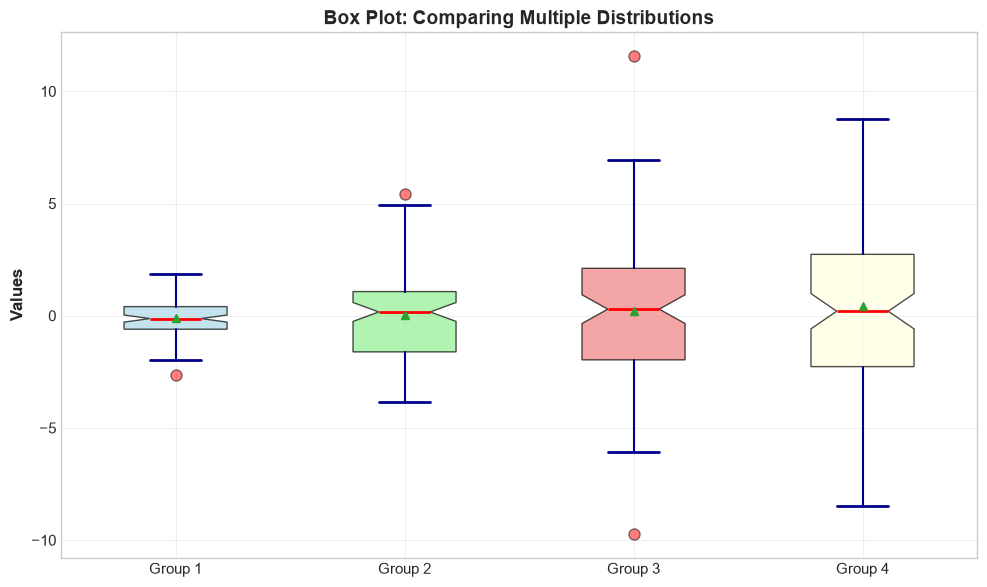

In [2]:
# Generate sample data
np.random.seed(42)
data = [np.random.normal(0, std, 100) for std in range(1, 5)]

fig, ax = plt.subplots(figsize=(10, 6))

# Create box plot
bp = ax.boxplot(data, tick_labels=['Group 1', 'Group 2', 'Group 3', 'Group 4'],
                patch_artist=True, notch=True, showmeans=True)

# Customize colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers and outliers
for whisker in bp['whiskers']:
    whisker.set(color='darkblue', linewidth=1.5)
    
for cap in bp['caps']:
    cap.set(color='darkblue', linewidth=2)
    
for median in bp['medians']:
    median.set(color='red', linewidth=2)
    
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='red', markersize=8, alpha=0.5)

ax.set_ylabel('Values', fontsize=12, fontweight='bold')
ax.set_title('Box Plot: Comparing Multiple Distributions', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎻 2. Violin Plot

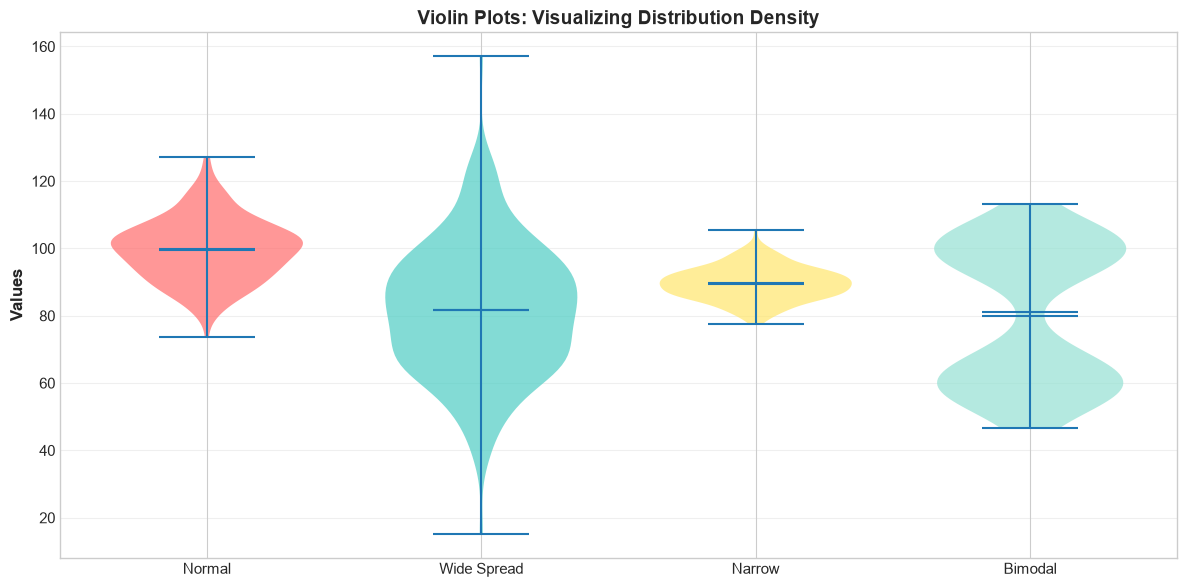

In [3]:
# Generate sample data with different distributions
np.random.seed(42)
data1 = np.random.normal(100, 10, 200)
data2 = np.random.normal(80, 20, 200)
data3 = np.random.normal(90, 5, 200)
data4 = np.concatenate([np.random.normal(60, 5, 100), np.random.normal(100, 5, 100)])  # Bimodal

data_violin = [data1, data2, data3, data4]

fig, ax = plt.subplots(figsize=(12, 6))

# Create violin plot
parts = ax.violinplot(data_violin, positions=[1, 2, 3, 4], 
                      showmeans=True, showmedians=True, widths=0.7)

# Customize violin colors
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Normal', 'Wide Spread', 'Narrow', 'Bimodal'])
ax.set_ylabel('Values', fontsize=12, fontweight='bold')
ax.set_title('Violin Plots: Visualizing Distribution Density', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 📊 3. Box Plot vs Violin Plot Comparison

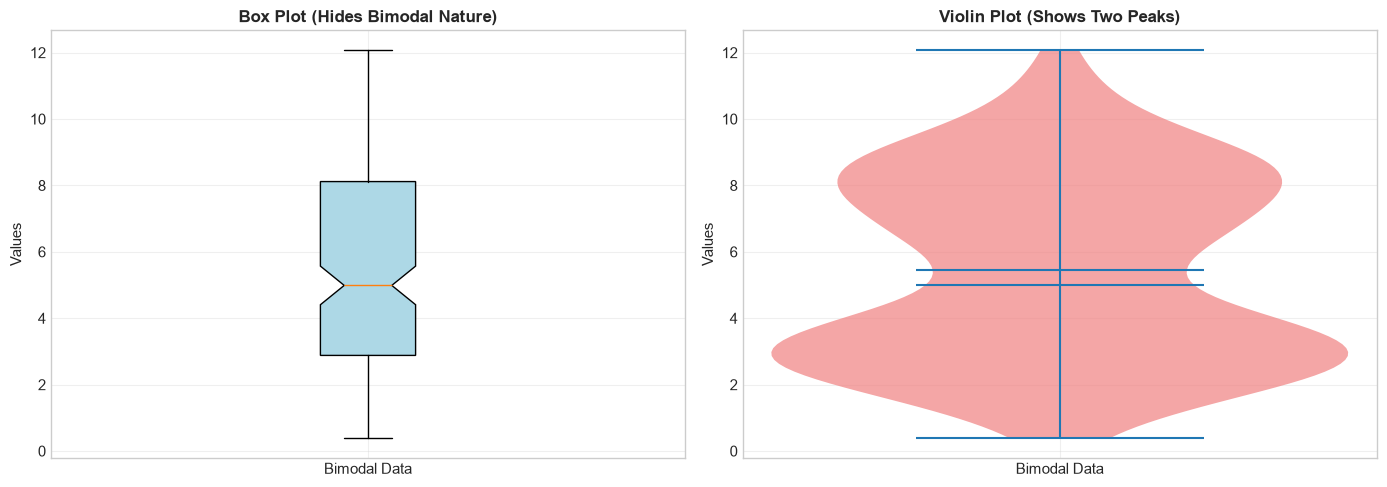

💡 Notice: The violin plot clearly shows two peaks, while the box plot obscures this information!


In [4]:
# Generate bimodal data to show advantage of violin plots
np.random.seed(42)
bimodal_data = np.concatenate([np.random.normal(3, 1, 100), 
                               np.random.normal(8, 1.5, 100)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
bp = ax1.boxplot([bimodal_data], patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('lightblue')
ax1.set_ylabel('Values', fontsize=11)
ax1.set_title('Box Plot (Hides Bimodal Nature)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(['Bimodal Data'])
ax1.grid(True, alpha=0.3)

# Violin plot
parts = ax2.violinplot([bimodal_data], showmeans=True, showmedians=True)
parts['bodies'][0].set_facecolor('lightcoral')
parts['bodies'][0].set_alpha(0.7)
ax2.set_ylabel('Values', fontsize=11)
ax2.set_title('Violin Plot (Shows Two Peaks)', fontsize=12, fontweight='bold')
ax2.set_xticks([1])
ax2.set_xticklabels(['Bimodal Data'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Notice: The violin plot clearly shows two peaks, while the box plot obscures this information!")

## 🔄 4. Horizontal Box Plots

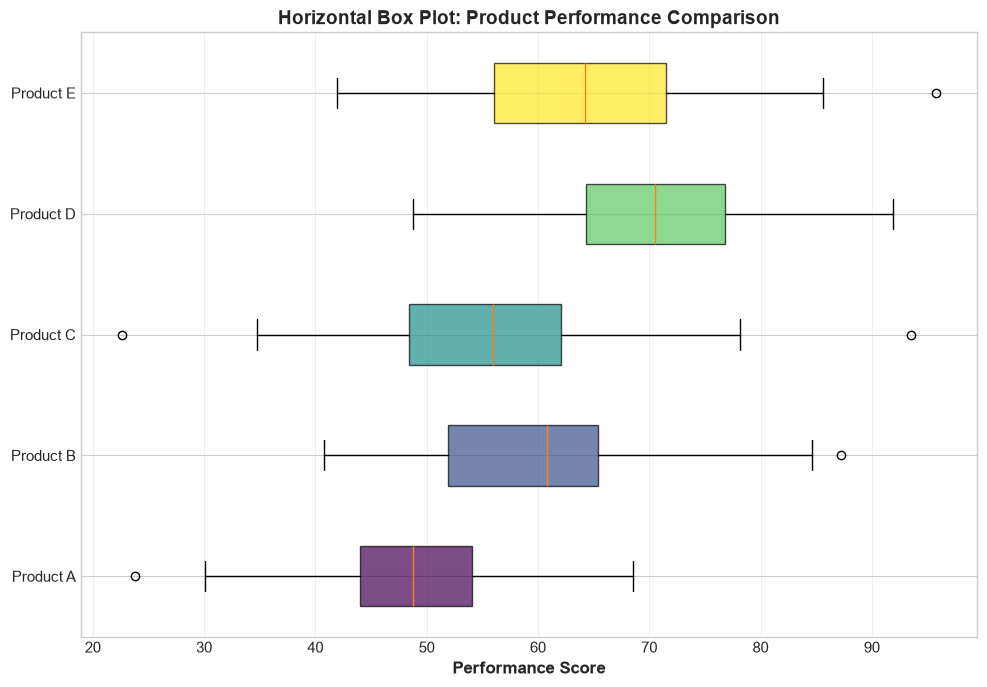

In [5]:
# Create sample data for different categories
np.random.seed(42)
categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
data = [np.random.normal(loc, 10, 100) for loc in [50, 60, 55, 70, 65]]

fig, ax = plt.subplots(figsize=(10, 7))

# Create horizontal box plot
bp = ax.boxplot(data, orientation="horizontal", patch_artist=True, tick_labels=categories)

# Color boxes with gradient
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_title('Horizontal Box Plot: Product Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 📈 5. Real-World Example: Test Scores by Class

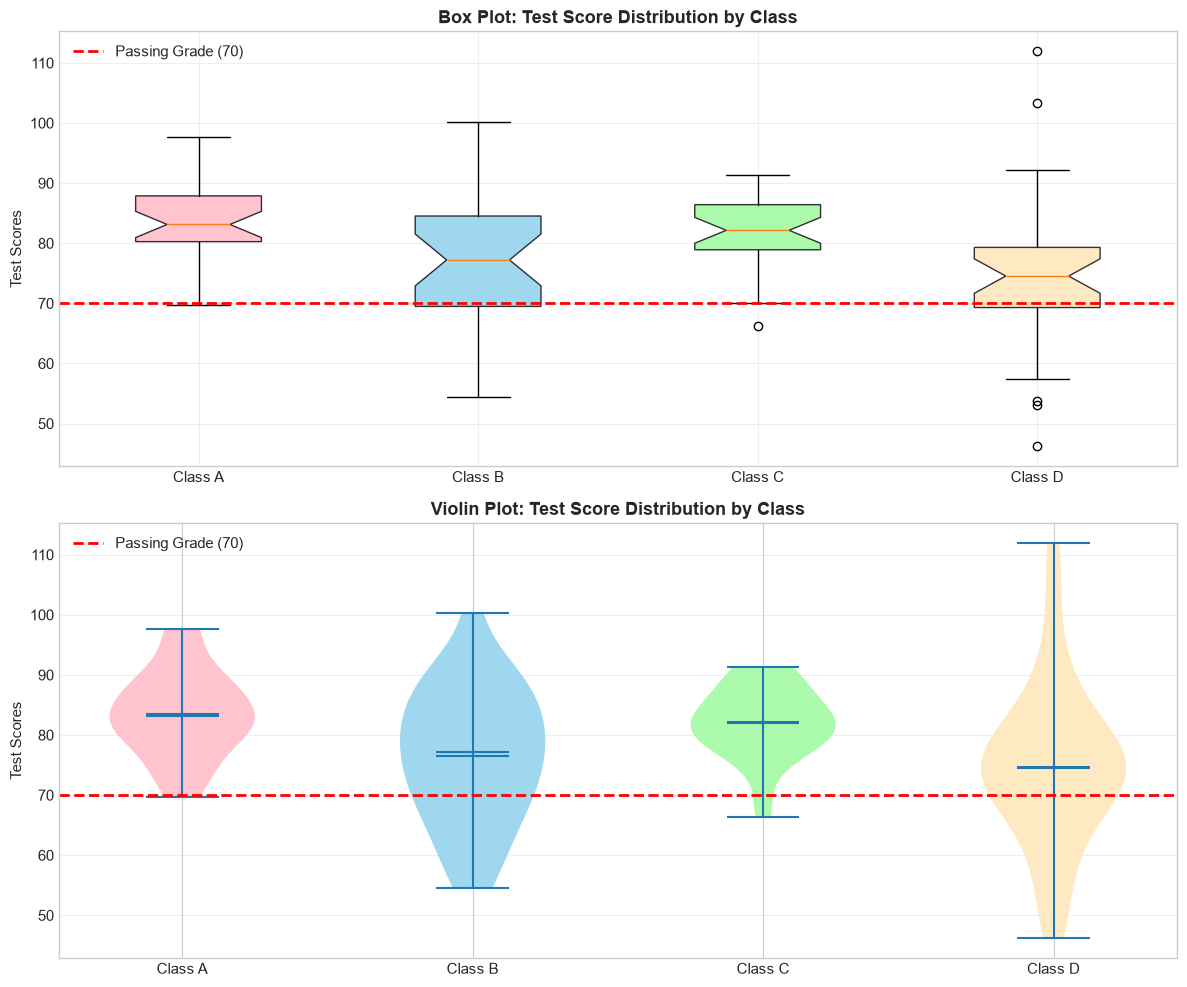


📊 Summary Statistics:

         Class A     Class B    Class C     Class D
count  30.000000   30.000000  30.000000   30.000000
mean   83.494825   76.546050  82.077309   74.696226
std     7.200051   11.173226   5.951898   13.632329
min    69.693758   54.483959  66.281529   46.218432
25%    80.271593   69.490636  78.915148   69.303604
50%    83.126839   77.225127  82.153663   74.540808
75%    87.882683   84.535941  86.426267   79.310310
max    97.633703  100.227338  91.387862  111.948632


In [6]:
# Simulate test scores for different classes
np.random.seed(42)
class_a = np.random.normal(85, 8, 30)
class_b = np.random.normal(78, 12, 30)
class_c = np.random.normal(82, 6, 30)
class_d = np.random.normal(75, 15, 30)

# Combine into DataFrame
df_scores = pd.DataFrame({
    'Class A': class_a,
    'Class B': class_b,
    'Class C': class_c,
    'Class D': class_d
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Box plot
bp = ax1.boxplot([df_scores[col] for col in df_scores.columns], 
                  tick_labels=df_scores.columns, patch_artist=True, notch=True)
colors = ['#FFB6C1', '#87CEEB', '#98FB98', '#FFE4B5']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax1.axhline(y=70, color='red', linestyle='--', linewidth=2, label='Passing Grade (70)')
ax1.set_ylabel('Test Scores', fontsize=11)
ax1.set_title('Box Plot: Test Score Distribution by Class', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Violin plot
parts = ax2.violinplot([df_scores[col] for col in df_scores.columns], 
                       positions=[1, 2, 3, 4], showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.8)

ax2.axhline(y=70, color='red', linestyle='--', linewidth=2, label='Passing Grade (70)')
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(df_scores.columns)
ax2.set_ylabel('Test Scores', fontsize=11)
ax2.set_title('Violin Plot: Test Score Distribution by Class', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Summary Statistics:\n")
print(df_scores.describe())

## 🎨 6. Customized Box Plot with Annotations

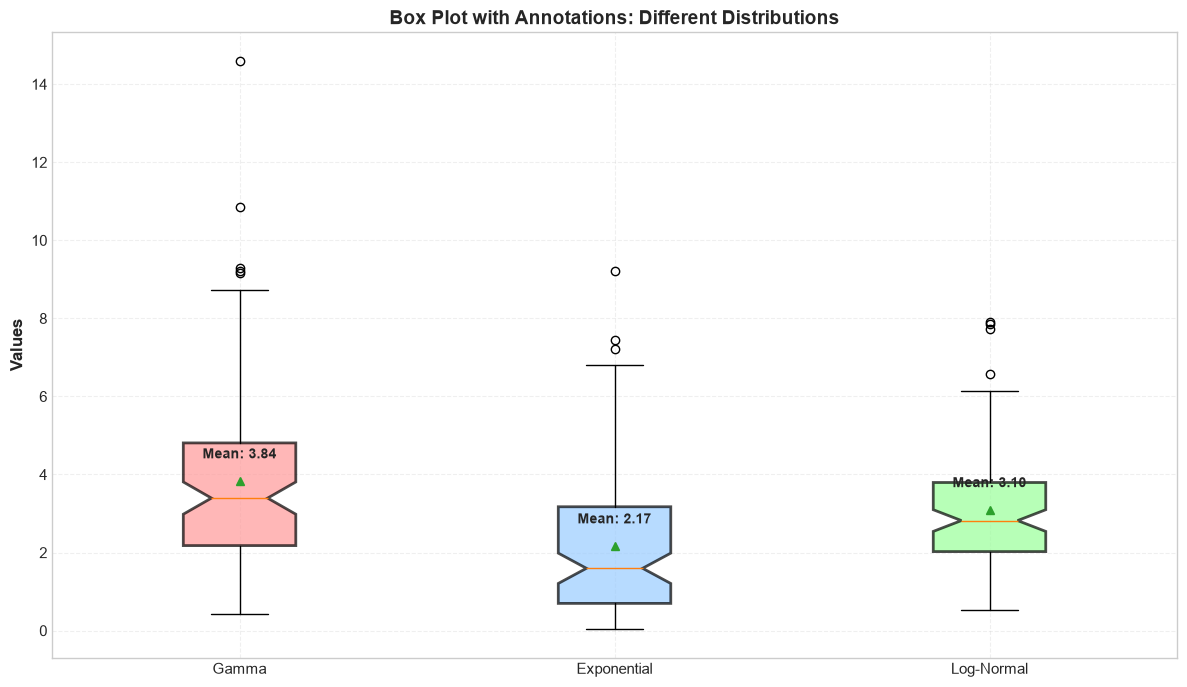

In [7]:
# Generate data
np.random.seed(42)
data = [np.random.gamma(2, 2, 100), 
        np.random.exponential(2, 100),
        np.random.lognormal(1, 0.5, 100)]

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(data, tick_labels=['Gamma', 'Exponential', 'Log-Normal'],
                patch_artist=True, notch=True, showmeans=True)

# Customize
colors = ['#FF9999', '#99CCFF', '#99FF99']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(2)

# Add mean values as text
means = [np.mean(d) for d in data]
for i, mean in enumerate(means, 1):
    ax.text(i, mean + 0.5, f'Mean: {mean:.2f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Values', fontsize=12, fontweight='bold')
ax.set_title('Box Plot with Annotations: Different Distributions', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 🎯 Key Takeaways

- ✅ **Box plots** show 5-number summary: min, Q1, median, Q3, max
- ✅ **Violin plots** reveal the full distribution shape and density
- ✅ Use `notch=True` in box plots to show confidence interval around median
- ✅ Set `showmeans=True` to display mean alongside median
- ✅ Violin plots are better for detecting multimodal distributions
- ✅ Use horizontal orientation (`vert=False`) for better label readability
- ✅ Both plot types are excellent for comparing multiple groups

## 💡 Try It Yourself

1. Create box plots for your own datasets
2. Compare test performance across different groups
3. Detect outliers using box plots
4. Use violin plots to show complex distributions
5. Combine box and violin plots in the same figure for comprehensive analysis